# 광명 시설물 데이터 전처리 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows
# plt.rcParams['font.family'] = 'AppleGothic'  # Mac
plt.rcParams['axes.unicode_minus'] = False

## 1) 데이터 구조 확인 및 스케일링 방법 비교

In [2]:
# final 광명시 데이터 불러오기
final_df = pd.read_csv('./raw-data/5_gwangmyung_final_dataset.csv', encoding='cp949')
print(f"shape: {final_df.shape}")
final_df.head()

shape: (51, 24)


,시설물명,위도,경도,과속방지턱,도로적색표면,무단횡단방지펜스,보호구역표지판,신호등,옐로카펫,횡단보도,...,사망자수,중상자수,경상자수,동,총인구수,0~4세,5~9세,10~14세,어린이 총인구,어린이 비율(%)
0,빛가온초등학교,37.413690,126.882026,10,13,19,0,47,1,30,...,0,0,0,일직동,21148,851,979,1264,3094,14.630225
1,빛가온유치원,37.416952,126.888265,1,4,12,0,35,0,10,...,0,0,0,일직동,21148,851,979,1264,3094,14.630225
2,광명생명숲어린이집,37.432309,126.877817,2,0,0,0,11,0,6,...,0,0,0,소하동,54145,1089,1725,2722,5536,10.224397
3,큰별어린이집,37.436146,126.877327,2,3,9,0,7,0,1,...,0,0,0,소하동,54145,1089,1725,2722,5536,10.224397
4,충현초등학교,37.432490,126.884627,7,7,0,0,30,1,14,...,0,0,0,소하동,54145,1089,1725,2722,5536,10.224397


In [3]:
# feature / target / 제외 컬럼 정의
FACILITY_FEATURES = ['도로안전표지', '도로적색표면', '무단횡단방지펜스', '무인교통단속카메라',
                     '보호구역표지판', '생활안전CCTV', '신호등', '옐로카펫', '횡단보도']

POPULATION_FEATURES_TOTAL = ['총인구수', '0~4세', '5~9세', '10~14세', '어린이 총인구', '어린이 비율(%)']
POPULATION_FEATURES = ['어린이 비율(%)']  # 총인구수
TARGET_COLS = ['발생건수', '사상자수', '사망및중상자수', '사망자수', '중상자수', '경상자수']

FEATURE_COLS = FACILITY_FEATURES + POPULATION_FEATURES
FEATURE_COLS_EXCEPT_TOTAL = FACILITY_FEATURES + POPULATION_FEATURES  # 총인구수 제외

### 1-1. 기초 통계량

In [4]:
# FACILITY_FEATURES 중 데이터에 없는 컬럼을 0으로 채우기
missing_cols = [col for col in FACILITY_FEATURES if col not in final_df.columns]
for col in missing_cols:
    final_df[col] = 0
print(f"0으로 채운 컬럼: {missing_cols}")

0으로 채운 컬럼: ['도로안전표지', '무인교통단속카메라', '생활안전CCTV']


In [5]:
from scipy import stats

# 기초 통계량 + 왜도(skewness) + 첨도(kurtosis) 한 번에 요약
summary = final_df[FEATURE_COLS].describe().T
summary['skewness'] = final_df[FEATURE_COLS].skew()
summary['kurtosis'] = final_df[FEATURE_COLS].kurt()
summary['zero_ratio'] = (final_df[FEATURE_COLS] == 0).mean()  # 0 비율

# 왜도 기준 판정
def skew_label(s):
    if abs(s) < 0.5:
        return '대칭'
    elif abs(s) < 1.0:
        return '약간 치우침'
    else:
        return '강하게 치우침'

summary['skew_판정'] = summary['skewness'].apply(skew_label)

summary[['mean', 'std', 'min', 'max', 'skewness', 'kurtosis', 'zero_ratio', 'skew_판정']]

,mean,std,min,max,skewness,kurtosis,zero_ratio,skew_판정
도로안전표지,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,대칭
도로적색표면,6.490196,4.369771,0.000000,19.000000,1.000136,0.716287,0.058824,강하게 치우침
무단횡단방지펜스,11.686275,10.402865,0.000000,41.000000,1.068858,0.900212,0.156863,강하게 치우침
무인교통단속카메라,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,대칭
보호구역표지판,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,대칭
생활안전CCTV,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,대칭
신호등,19.941176,21.240915,0.000000,93.000000,1.642946,2.553699,0.137255,강하게 치우침
옐로카펫,0.627451,1.019035,0.000000,4.000000,1.999943,3.802000,0.607843,강하게 치우침
횡단보도,10.549020,8.302563,0.000000,32.000000,1.001495,0.570516,0.019608,강하게 치우침
어린이 비율(%),10.278802,2.279136,3.337379,14.630225,-1.229242,3.513775,0.000000,강하게 치우침


In [6]:
import os

output_dir = '../preprocessing/outputs'
os.makedirs(output_dir, exist_ok=True)

save_df = summary[['mean', 'std', 'min', 'max', 'skewness', 'kurtosis', 'zero_ratio', 'skew_판정']]
save_df.to_csv(f'{output_dir}/facility_feature_summary_gm.csv', encoding='utf-8-sig')
print(f"저장 완료: {output_dir}/feature_summary_gm.csv")

저장 완료: ../preprocessing/outputs/feature_summary_gm.csv


### 1-2. Feature별 히스토그램 (시설물)

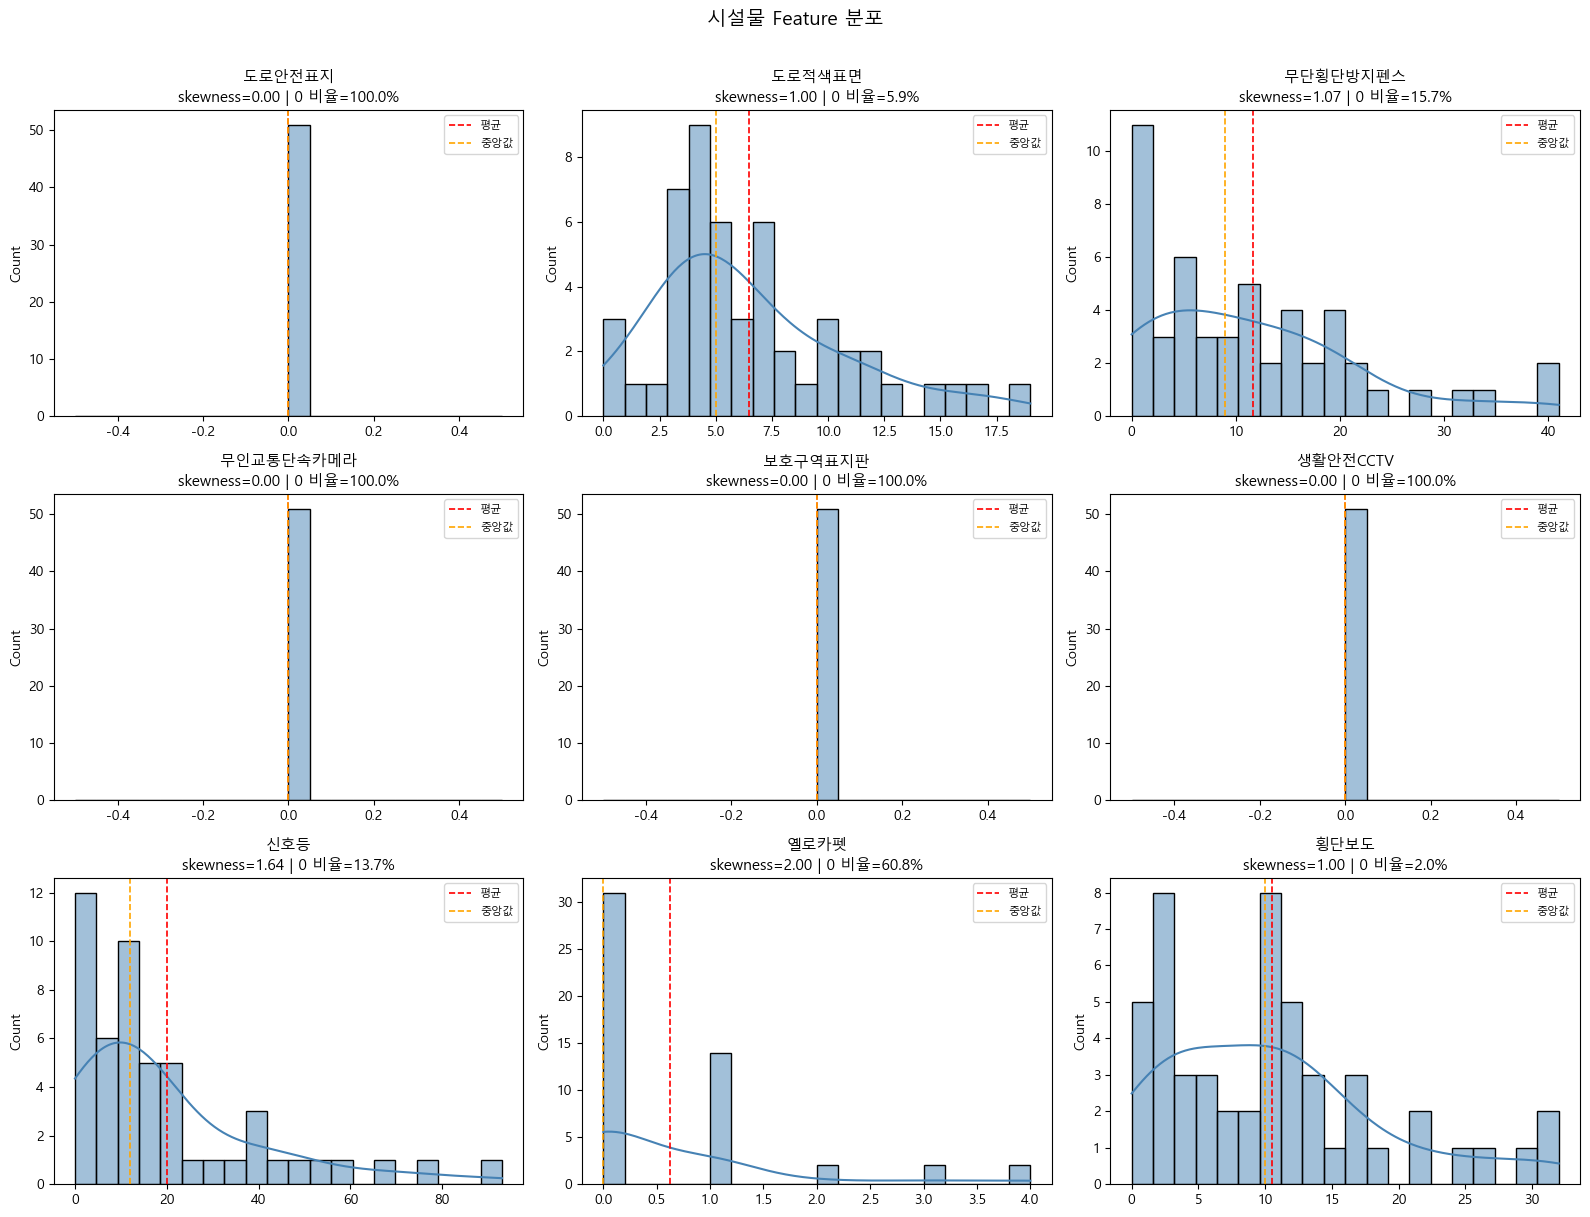

In [7]:
n_cols = 3
n_rows = (len(FACILITY_FEATURES) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(FACILITY_FEATURES):
    ax = axes[i]
    skew_val = final_df[col].skew()
    zero_pct = (final_df[col] == 0).mean() * 100

    sns.histplot(final_df[col], kde=True, bins=20, ax=ax, color='steelblue')

    ax.set_title(f'{col}\nskewness={skew_val:.2f} | 0 비율={zero_pct:.1f}%', fontsize=11)
    ax.set_xlabel('')
    ax.axvline(final_df[col].mean(), color='red', linestyle='--', linewidth=1.2, label='평균')
    ax.axvline(final_df[col].median(), color='orange', linestyle='--', linewidth=1.2, label='중앙값')
    ax.legend(fontsize=8)

# 남는 축 숨기기
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('시설물 Feature 분포', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [8]:
# 시설물 경향성 플롯 저장
fig_output_dir = '../preprocessing/outputs/visualization'
os.makedirs(fig_output_dir, exist_ok=True)
fig.savefig(f'{fig_output_dir}/facility_feature_distributions_gm.png', bbox_inches='tight', dpi=300)

### 1-3. Feature별 히스토그램 (인구)

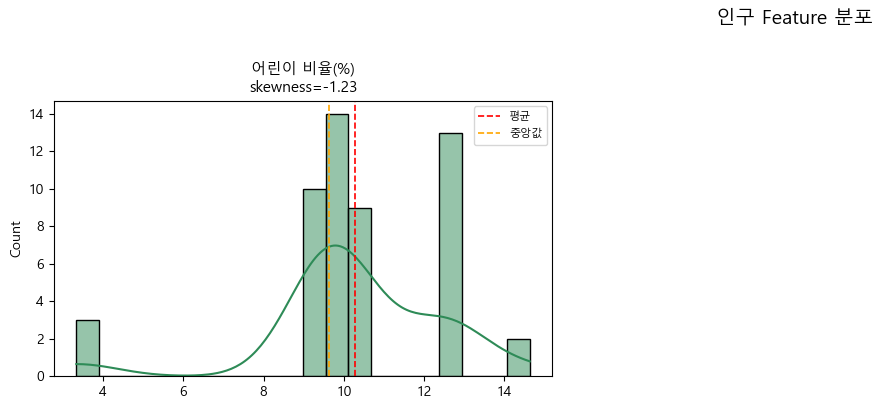

In [9]:
n_cols = 3
n_rows = (len(POPULATION_FEATURES) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(POPULATION_FEATURES):
    ax = axes[i]
    skew_val = final_df[col].skew()

    sns.histplot(final_df[col], kde=True, bins=20, ax=ax, color='seagreen')

    ax.set_title(f'{col}\nskewness={skew_val:.2f}', fontsize=11)
    ax.set_xlabel('')
    ax.axvline(final_df[col].mean(), color='red', linestyle='--', linewidth=1.2, label='평균')
    ax.axvline(final_df[col].median(), color='orange', linestyle='--', linewidth=1.2, label='중앙값')
    ax.legend(fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('인구 Feature 분포', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 1-4. Boxplot으로 이상치 확인

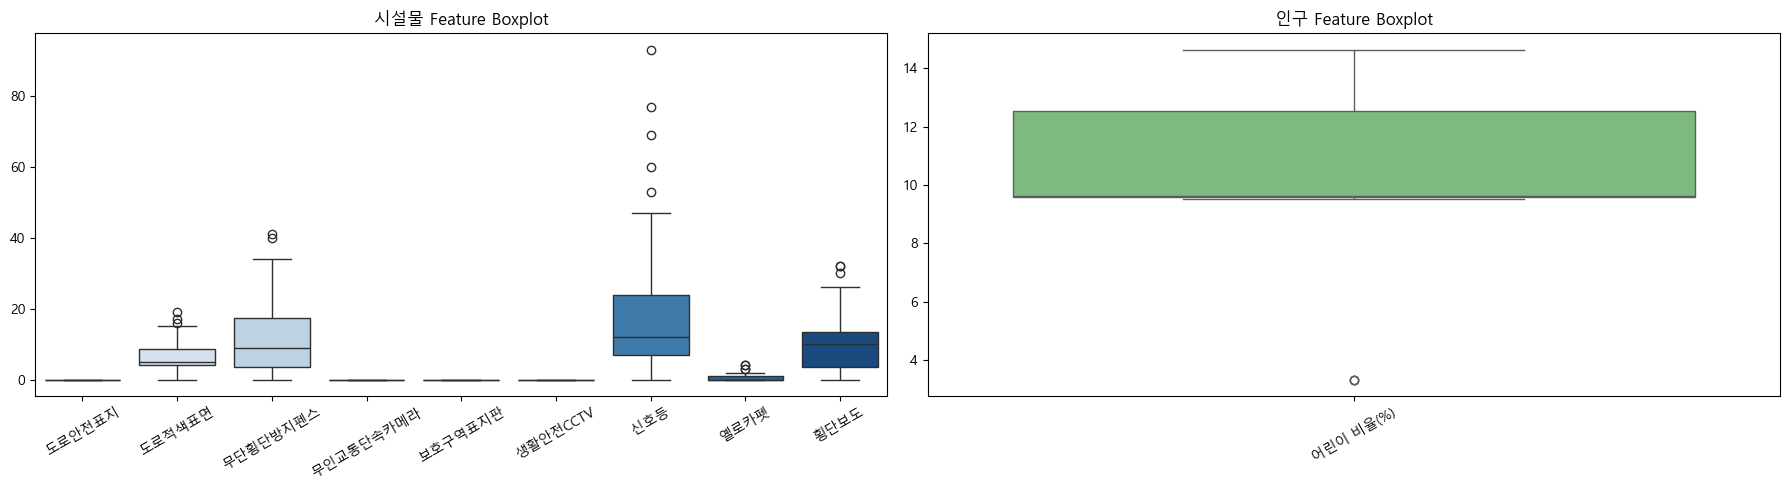


[IQR 기반 이상치 개수]
  도로안전표지              : 0개 (0.0%)
  도로적색표면              : 3개 (5.9%)
  무단횡단방지펜스            : 2개 (3.9%)
  무인교통단속카메라           : 0개 (0.0%)
  보호구역표지판             : 0개 (0.0%)
  생활안전CCTV            : 0개 (0.0%)
  신호등                 : 5개 (9.8%)
  옐로카펫                : 4개 (7.8%)
  횡단보도                : 3개 (5.9%)
  어린이 비율(%)           : 3개 (5.9%)


In [10]:
# 시설물 feature boxplot (이상치 탐지)
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# 시설물
sns.boxplot(data=final_df[FACILITY_FEATURES], ax=axes[0], palette='Blues')
axes[0].set_title('시설물 Feature Boxplot', fontsize=12)
axes[0].tick_params(axis='x', rotation=30)

# 인구 (스케일 차이가 크므로 분리)
sns.boxplot(data=final_df[POPULATION_FEATURES], ax=axes[1], palette='Greens')
axes[1].set_title('인구 Feature Boxplot', fontsize=12)
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

# IQR 기반 이상치 개수 요약
print("\n[IQR 기반 이상치 개수]")
for col in FEATURE_COLS:
    Q1, Q3 = final_df[col].quantile(0.25), final_df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_outliers = ((final_df[col] < Q1 - 1.5 * IQR) | (final_df[col] > Q3 + 1.5 * IQR)).sum()
    print(f"  {col:20s}: {n_outliers}개 ({n_outliers/len(final_df)*100:.1f}%)")

### 1-5. 정규성 검정 (Shapiro-Wilk)

In [11]:
# Shapiro-Wilk: p-value > 0.05 이면 정규분포로 볼 수 있음
# 샘플 수가 작을 때 적합 (n < 5000)
print(f"데이터 수: {len(final_df)}행\n")
print(f"{'Feature':<25} {'W통계량':>10} {'p-value':>12} {'정규분포?':>10}")
print("-" * 60)

for col in FEATURE_COLS:
    stat, p = stats.shapiro(final_df[col].dropna())
    is_normal = "O" if p > 0.05 else "X"
    print(f"{col:<25} {stat:>10.4f} {p:>12.4f} {is_normal:>10}")

데이터 수: 51행

Feature                         W통계량      p-value      정규분포?
------------------------------------------------------------
도로안전표지                        1.0000       1.0000          O
도로적색표면                        0.9171       0.0017          X
무단횡단방지펜스                      0.8998       0.0004          X
무인교통단속카메라                     1.0000       1.0000          O
보호구역표지판                       1.0000       1.0000          O
생활안전CCTV                      1.0000       1.0000          O
신호등                           0.8182       0.0000          X
옐로카펫                          0.6520       0.0000          X
횡단보도                          0.9035       0.0006          X
어린이 비율(%)                     0.7670       0.0000          X


c:\Users\USER\AppData\Local\Programs\Python\Python311\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: Input data has range zero. The results may not be accurate.
  res = hypotest_fun_out(*samples, **kwds)


### 1-6. Feature 간 상관관계 확인

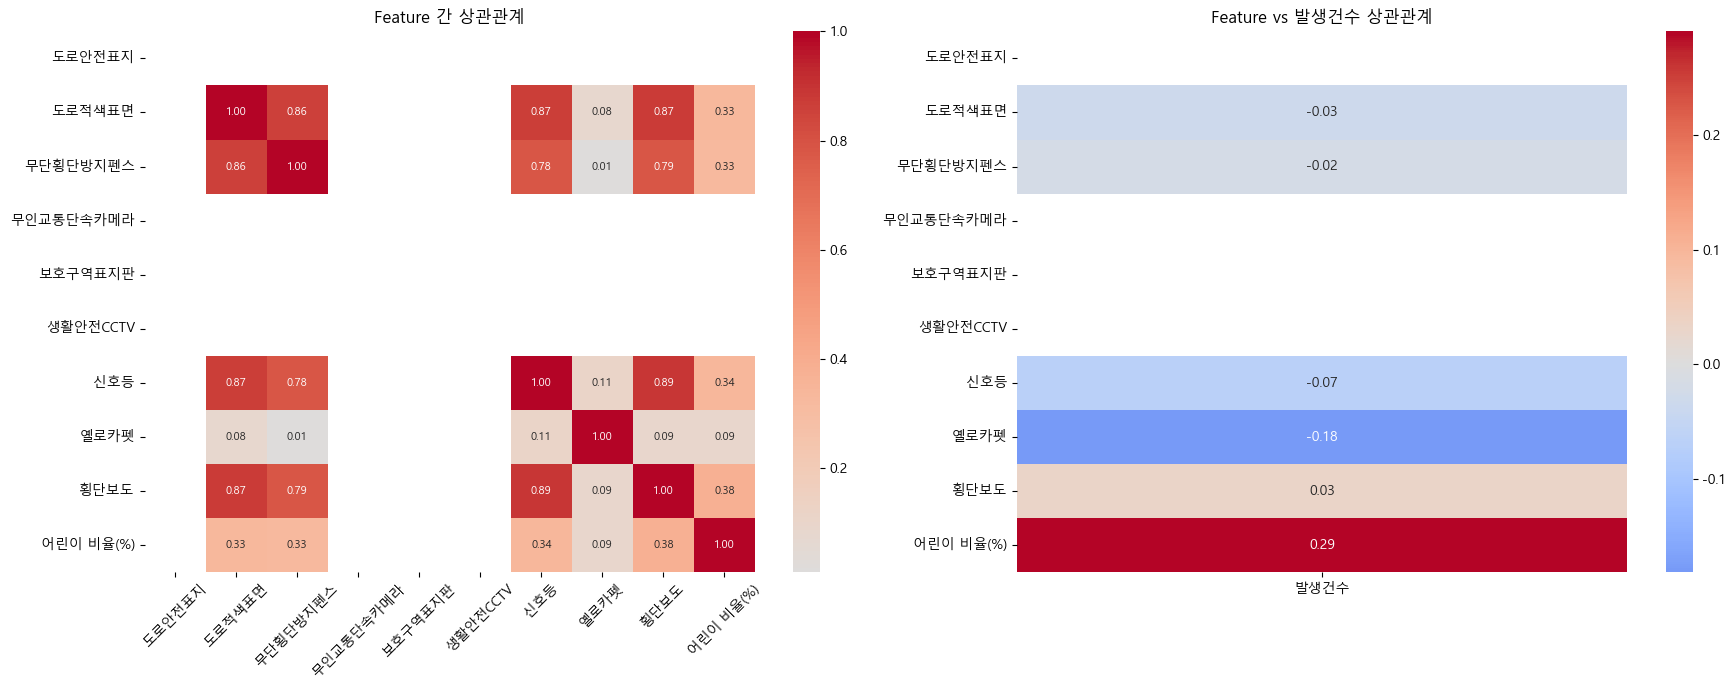

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# feature 간 상관관계
corr_feat = final_df[FEATURE_COLS_EXCEPT_TOTAL].corr()
sns.heatmap(corr_feat, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=axes[0], annot_kws={'size': 8})
axes[0].set_title('Feature 간 상관관계', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)

# feature vs 발생건수 상관관계
corr_target = final_df[FEATURE_COLS_EXCEPT_TOTAL + ['발생건수']].corr()[['발생건수']].drop('발생건수')
sns.heatmap(corr_target, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=axes[1], annot_kws={'size': 10})
axes[1].set_title('Feature vs 발생건수 상관관계', fontsize=12)

plt.tight_layout()
plt.show()

## 2) 데이터 스케일링

### 2-1. 스케일링 대상 분리

In [13]:
from sklearn.preprocessing import StandardScaler

# 1-1 결과 기준: skewness > 1 → Log 변환 후 StandardScaler
LOG_FEATURES = ['무인교통단속카메라', '보호구역표지판', '생활안전CCTV', '옐로카펫']

# 나머지 feature → StandardScaler 바로 적용
STANDARD_FEATURES = [col for col in FEATURE_COLS if col not in LOG_FEATURES]

print("[ Log(x+1) 변환 후 StandardScaler ]")
for col in LOG_FEATURES:
    print(f"  {col}  (skewness={final_df[col].skew():.2f})")

print("\n[ StandardScaler 바로 적용 ]")
for col in STANDARD_FEATURES:
    print(f"  {col}  (skewness={final_df[col].skew():.2f})")

[ Log(x+1) 변환 후 StandardScaler ]
  무인교통단속카메라  (skewness=0.00)
  보호구역표지판  (skewness=0.00)
  생활안전CCTV  (skewness=0.00)
  옐로카펫  (skewness=2.00)

[ StandardScaler 바로 적용 ]
  도로안전표지  (skewness=0.00)
  도로적색표면  (skewness=1.00)
  무단횡단방지펜스  (skewness=1.07)
  신호등  (skewness=1.64)
  횡단보도  (skewness=1.00)
  어린이 비율(%)  (skewness=-1.23)


### 2-2. 스케일링 적용

In [14]:
scaled_df = final_df.copy()

# --- Log(x+1) 변환 후 StandardScaler ---
scaler_log = StandardScaler()
log_transformed = np.log1p(scaled_df[LOG_FEATURES])
scaled_df[LOG_FEATURES] = scaler_log.fit_transform(log_transformed)

# --- StandardScaler 바로 적용 ---
scaler_std = StandardScaler()
scaled_df[STANDARD_FEATURES] = scaler_std.fit_transform(scaled_df[STANDARD_FEATURES])

print("스케일링 완료")
print(f"shape: {scaled_df.shape}")
scaled_df[FEATURE_COLS].head()

스케일링 완료
shape: (51, 27)


,도로안전표지,도로적색표면,무단횡단방지펜스,무인교통단속카메라,보호구역표지판,생활안전CCTV,신호등,옐로카펫,횡단보도,어린이 비율(%)
0,0.0,1.504559,0.710045,0.0,0.0,0.0,1.286577,0.709035,2.366080,1.928241
1,0.0,-0.575539,0.030458,0.0,0.0,0.0,0.716008,-0.726702,-0.066785,1.928241
2,0.0,-1.500027,-1.134549,0.0,0.0,0.0,-0.425130,-0.726702,-0.553357,-0.024108
3,0.0,-0.806661,-0.260794,0.0,0.0,0.0,-0.615319,-0.726702,-1.161574,-0.024108
4,0.0,0.117827,-1.134549,0.0,0.0,0.0,0.478271,0.709035,0.419788,-0.024108


### 2-3. 스케일링 전후 비교

In [15]:
# 스케일링 전후 skewness / mean / std 비교표
compare = pd.DataFrame({
    'skewness_전': final_df[FEATURE_COLS].skew(),
    'skewness_후': scaled_df[FEATURE_COLS].skew(),
    'mean_후':     scaled_df[FEATURE_COLS].mean(),
    'std_후':      scaled_df[FEATURE_COLS].std(),
})
compare['변환방식'] = compare.index.map(
    lambda c: 'Log+Standard' if c in LOG_FEATURES else 'Standard'
)
compare['skewness_개선'] = (compare['skewness_전'].abs() - compare['skewness_후'].abs()).round(3)

compare[['변환방식', 'skewness_전', 'skewness_후', 'skewness_개선', 'mean_후', 'std_후']].round(3)

,변환방식,skewness_전,skewness_후,skewness_개선,mean_후,std_후
도로안전표지,Standard,0.000,0.000,0.000,0.0,0.00
도로적색표면,Standard,1.000,1.000,0.000,0.0,1.01
무단횡단방지펜스,Standard,1.069,1.069,-0.000,0.0,1.01
무인교통단속카메라,Log+Standard,0.000,0.000,0.000,0.0,0.00
보호구역표지판,Log+Standard,0.000,0.000,0.000,0.0,0.00
생활안전CCTV,Log+Standard,0.000,0.000,0.000,0.0,0.00
신호등,Standard,1.643,1.643,-0.000,0.0,1.01
옐로카펫,Log+Standard,2.000,1.125,0.875,0.0,1.01
횡단보도,Standard,1.001,1.001,0.000,0.0,1.01
어린이 비율(%),Standard,-1.229,-1.229,-0.000,0.0,1.01


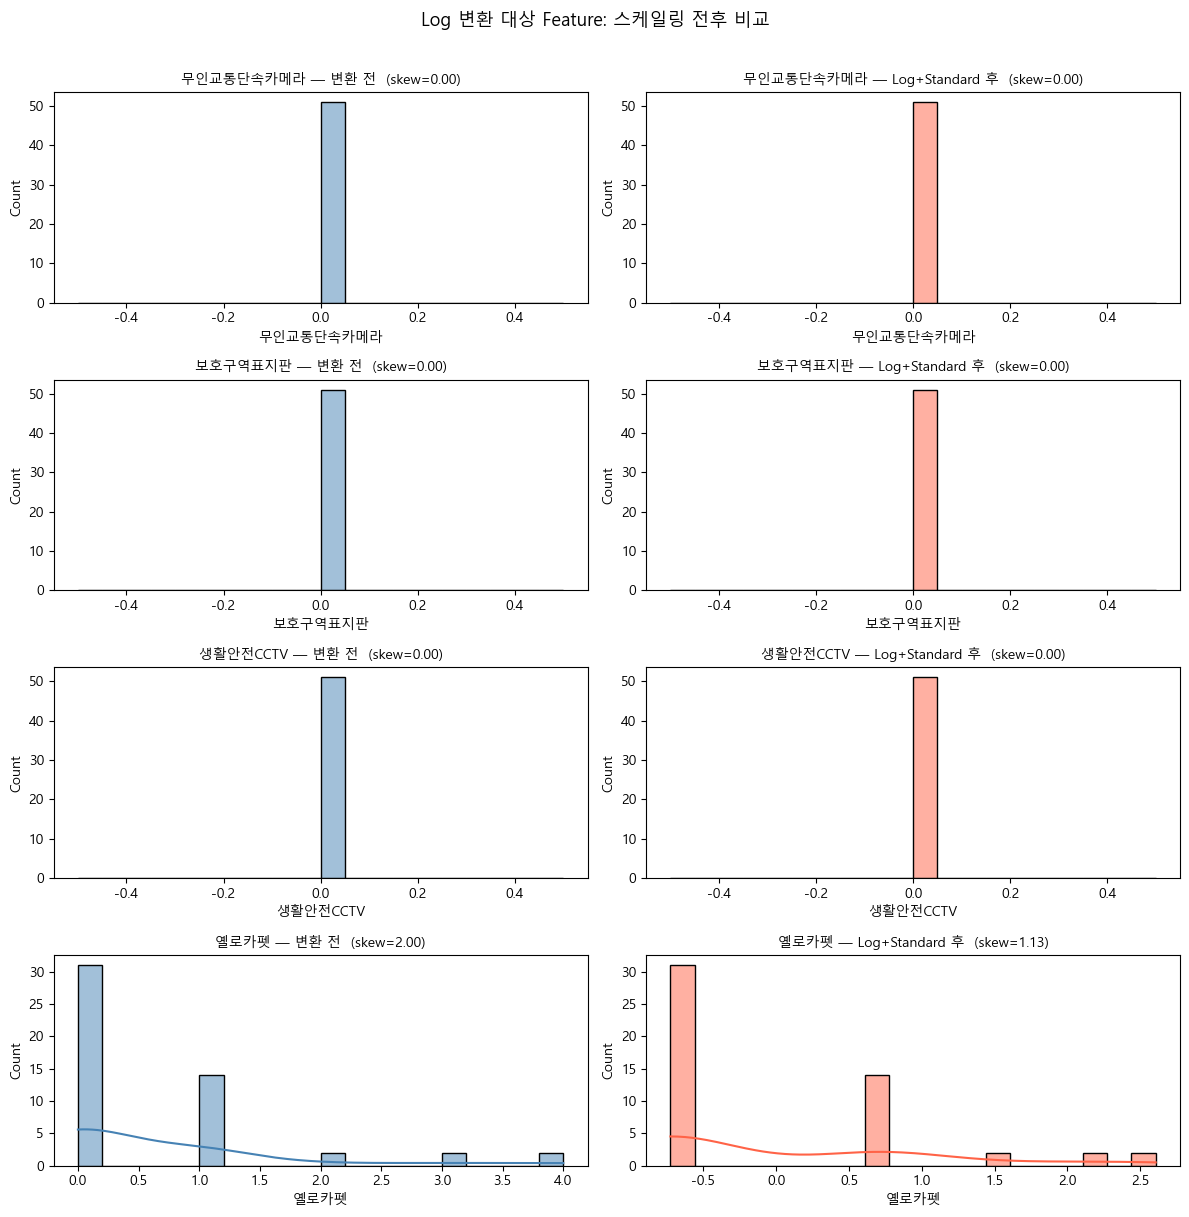

In [16]:
# 스케일링 전후 히스토그램 비교 (LOG_FEATURES만)
fig, axes = plt.subplots(len(LOG_FEATURES), 2, figsize=(12, len(LOG_FEATURES) * 3))

for i, col in enumerate(LOG_FEATURES):
    # 변환 전
    sns.histplot(final_df[col], kde=True, bins=20, ax=axes[i][0], color='steelblue')
    axes[i][0].set_title(f'{col} — 변환 전  (skew={final_df[col].skew():.2f})', fontsize=10)

    # 변환 후
    sns.histplot(scaled_df[col], kde=True, bins=20, ax=axes[i][1], color='tomato')
    axes[i][1].set_title(f'{col} — Log+Standard 후  (skew={scaled_df[col].skew():.2f})', fontsize=10)

plt.suptitle('Log 변환 대상 Feature: 스케일링 전후 비교', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

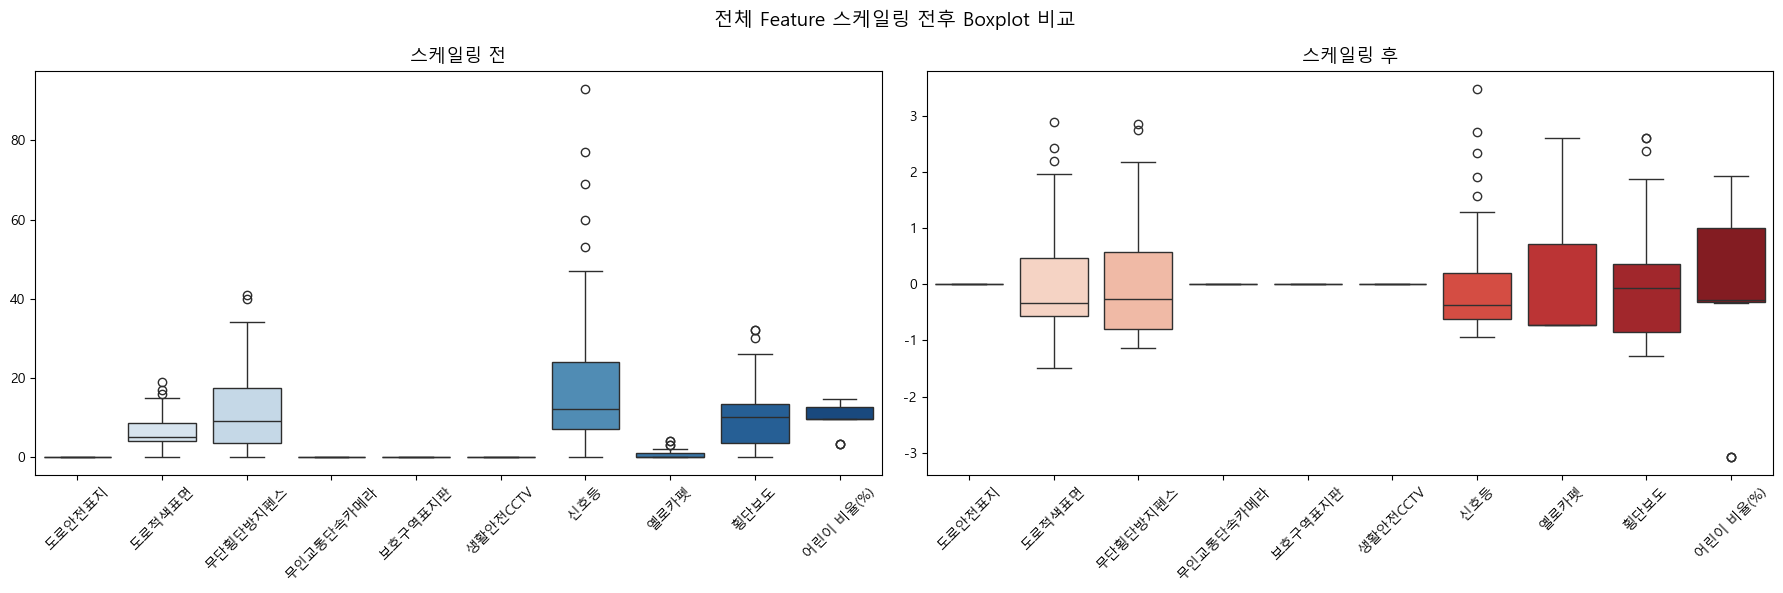

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.boxplot(data=final_df[FEATURE_COLS_EXCEPT_TOTAL], ax=axes[0], palette='Blues')
axes[0].set_title('스케일링 전', fontsize=13)
axes[0].tick_params(axis='x', rotation=45)

sns.boxplot(data=scaled_df[FEATURE_COLS_EXCEPT_TOTAL], ax=axes[1], palette='Reds')
axes[1].set_title('스케일링 후', fontsize=13)
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('전체 Feature 스케일링 전후 Boxplot 비교', fontsize=14)
plt.tight_layout()
plt.show()

### 2-4. 스케일링된 데이터 저장

In [18]:
save_cols = FEATURE_COLS + ['발생건수']
scaled_df[save_cols].to_csv(f'{output_dir}/gwangmyung_scaled.csv', index=False, encoding='utf-8-sig')
print(f"저장 완료: {output_dir}/gwangmyung_scaled.csv")
print(f"저장 컬럼: {save_cols}")

저장 완료: ../preprocessing/outputs/gwangmyung_scaled.csv
저장 컬럼: ['도로안전표지', '도로적색표면', '무단횡단방지펜스', '무인교통단속카메라', '보호구역표지판', '생활안전CCTV', '신호등', '옐로카펫', '횡단보도', '어린이 비율(%)', '발생건수']
